# Visualization Story: Geometry, Loss, and Dimension

**Name:**  Senthilnathan T

**Date:**  02-02-2026

In this notebook you will explore how prediction behaves through geometry, loss functions, and dimensionality using the California Housing dataset.

Your goal is to build a short visualization story supported by figures.

In [23]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
import seaborn as sns

import os

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(0)

## Task 1: Meet the Data

Explore the California Housing dataset.

- What does the dataset describe?
- What does the response variable look like?
- Are there visible patterns or surprises?


In [24]:
# Load the dataset
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="HouseValue")

print("Dataset Shape:", X.shape)
print("\nFeature Names:", data.feature_names)
print("\nDataset Description:")

print(data.DESCR[:500])
print("\n" + "="*60)
print("First few rows:")
X.head()

Dataset Shape: (20640, 8)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Dataset Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu

First few rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [25]:
# Basic statistics
print("Response Variable Statistics:")
print(y.describe())
print("\nFeature Statistics:")
X.describe()

Response Variable Statistics:
count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: HouseValue, dtype: float64

Feature Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


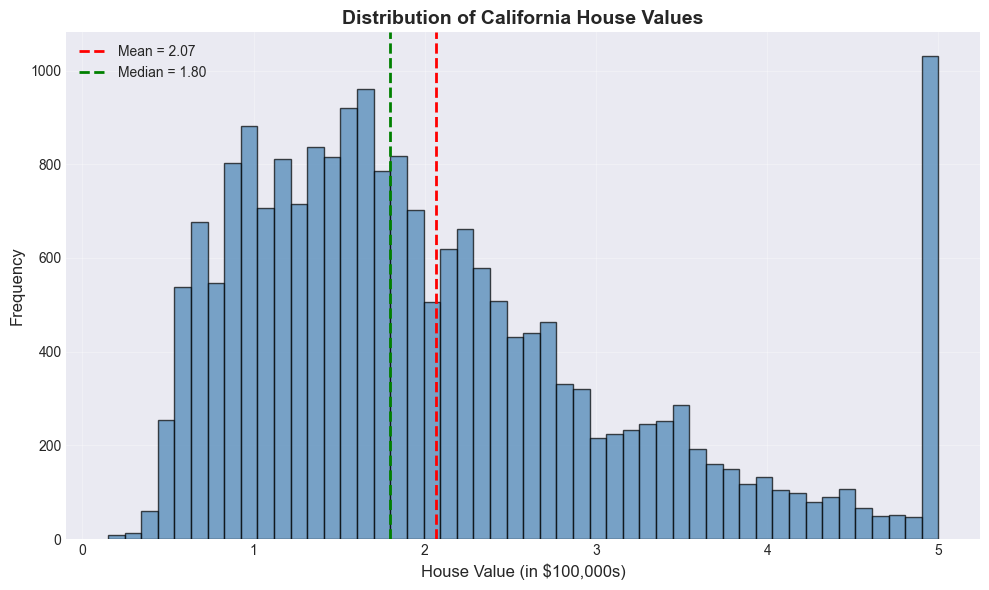

In [26]:
# Exploratory Plot 1: Distribution of House Values (Response Variable)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {y.mean():.2f}')
ax.axvline(y.median(), color='green', linestyle='--', linewidth=2, label=f'Median = {y.median():.2f}')
ax.set_xlabel('House Value (in $100,000s)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of California House Values', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('figs_results', 'a2_task1_fig1_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

## Observation: 

- The house value distribution is right-skewed with a notable ceiling at 5.0.

- This suggests data truncation at the upper end.

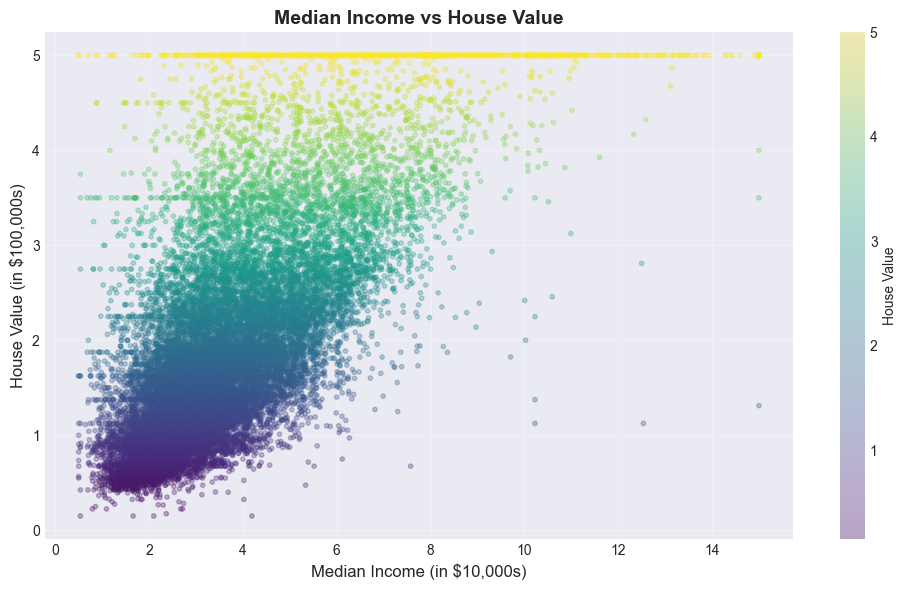

In [27]:
# Exploratory Plot 2: Median Income vs House Value
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(X['MedInc'], y, alpha=0.3, c=y, cmap='viridis', s=10)
ax.set_xlabel('Median Income (in $10,000s)', fontsize=12)
ax.set_ylabel('House Value (in $100,000s)', fontsize=12)
ax.set_title('Median Income vs House Value', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('House Value', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task1_fig2_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

## Observation: 

- Strong positive relationship between median income and house value (y).

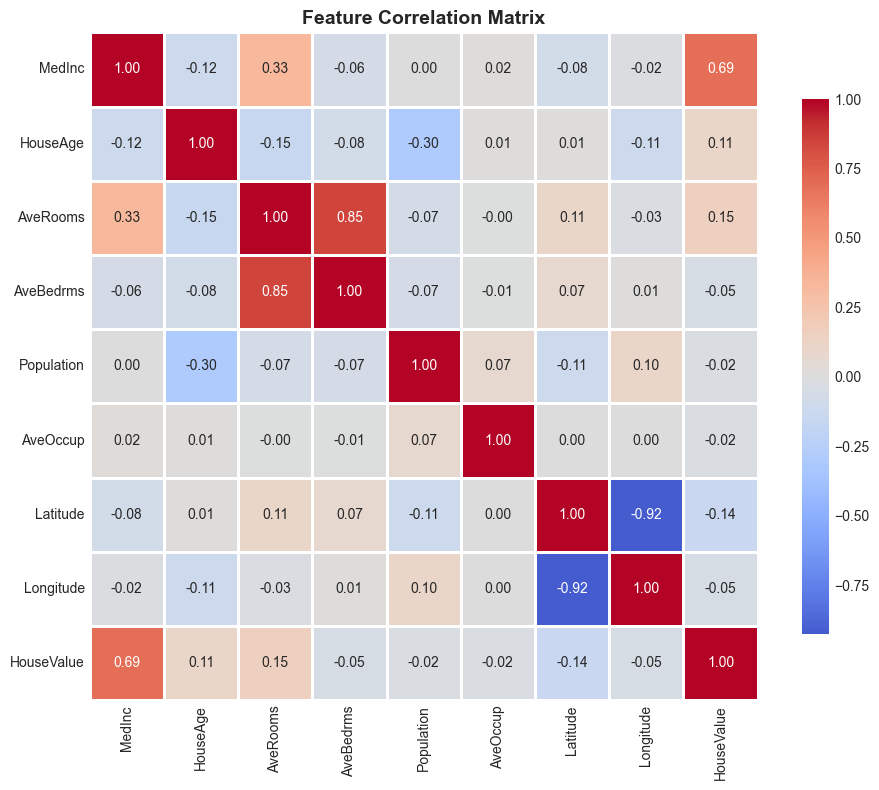

In [28]:
# Exploratory Plot 3: Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))
correlation_data = pd.concat([X, y], axis=1)
corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task1_fig3_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

## Observation: 
- AveRooms (Average No of Rooms) shows strongest correlation with HouseValue (0.69).
- Geographical features (Latitude, Longitude) show slight negative correlations.

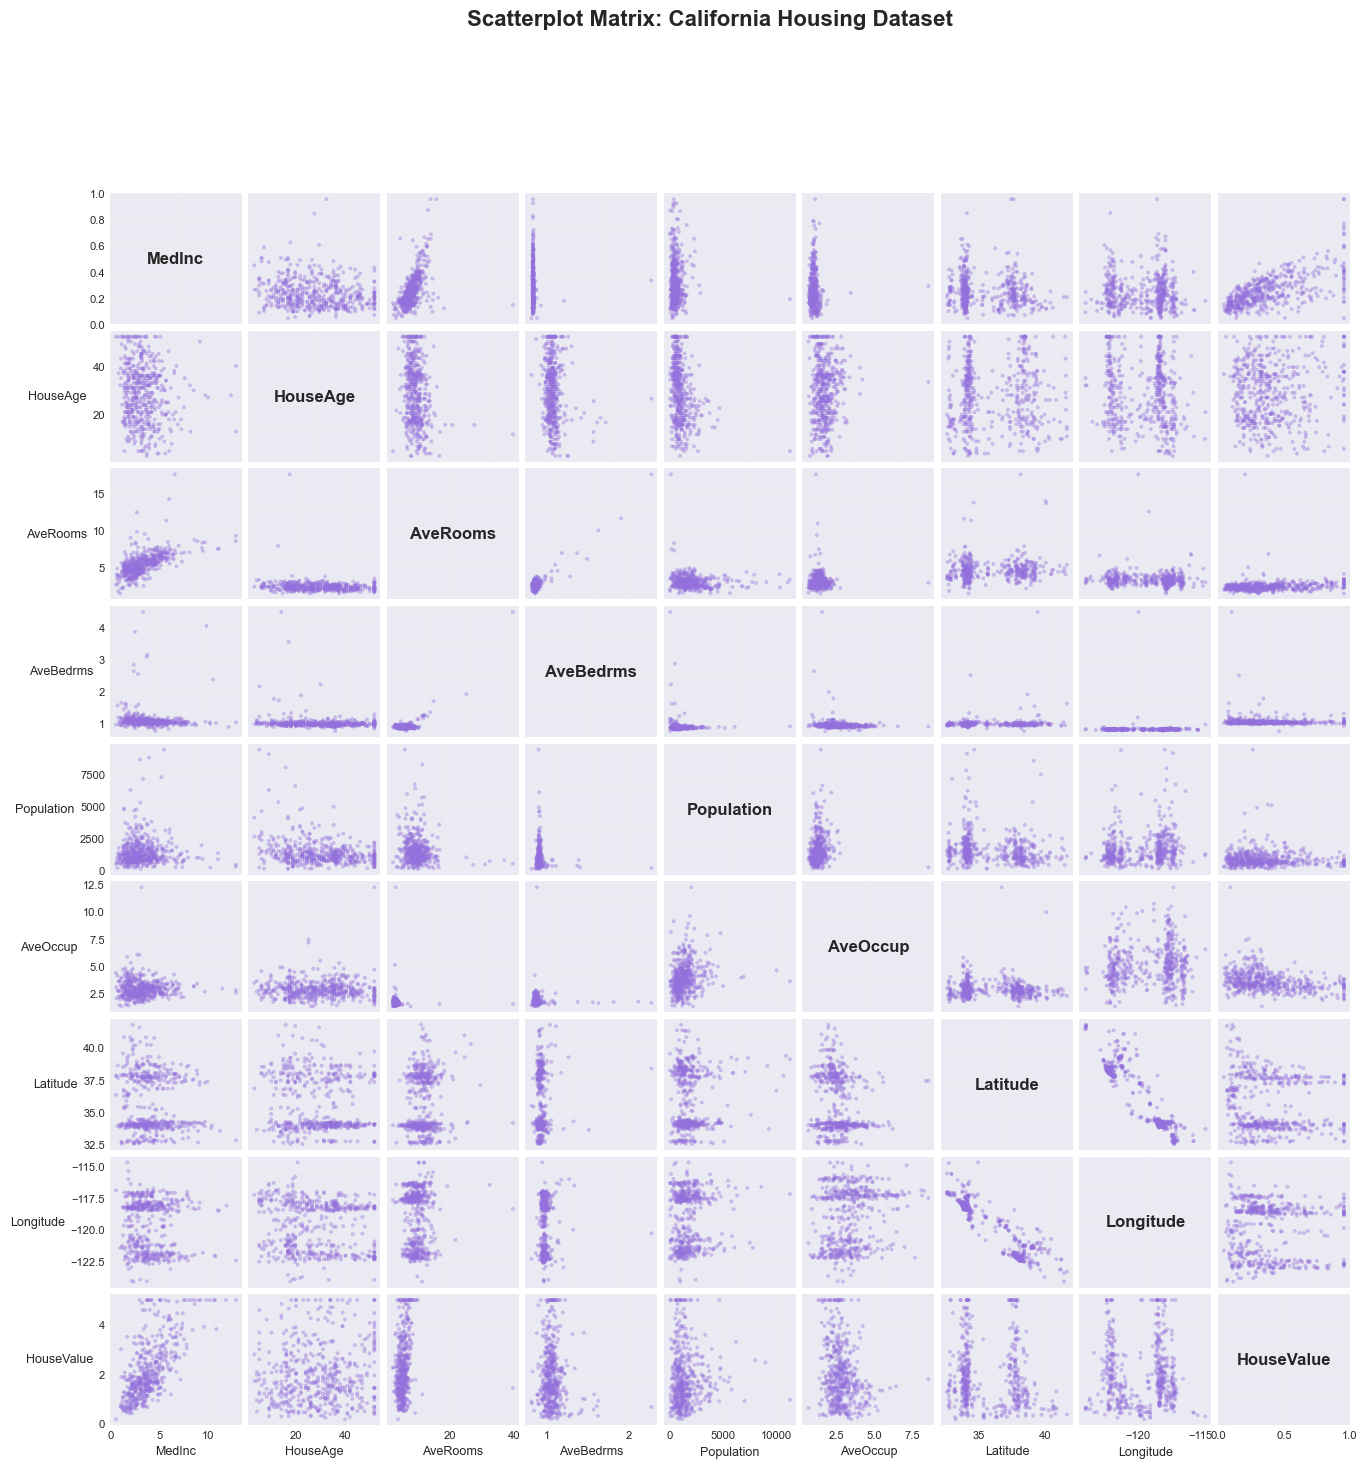

In [29]:
# Exploratory Plot 4: Scatterplot Matrix (Pairs Plot)
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Create figure with GridSpec for better control
fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(9, 9, figure=fig, hspace=0.05, wspace=0.05)

# Prepare data: combine features and response
features = data.feature_names
all_vars = list(features) + ['HouseValue']
plot_data = pd.concat([X, y], axis=1)

# Create scatterplot matrix
for i in range(9):
    for j in range(9):
        ax = fig.add_subplot(gs[i, j])
        
        if i == j:
            # Diagonal: variable names
            ax.text(0.5, 0.5, all_vars[i], 
                   horizontalalignment='center',
                   verticalalignment='center',
                   fontsize=12, fontweight='bold',
                   transform=ax.transAxes)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        else:
            # Off-diagonal: scatterplots
            x_var = all_vars[j]
            y_var = all_vars[i]
            
            # Subsample for cleaner visualization
            sample_idx = np.random.choice(len(plot_data), 500, replace=False)
            
            ax.scatter(plot_data[x_var].iloc[sample_idx], 
                      plot_data[y_var].iloc[sample_idx],
                      alpha=0.4, s=8, c='mediumpurple', edgecolors='none')
        
        # Remove tick labels except for edges
        if i < 8:  # Not bottom row
            ax.set_xticklabels([])
        else:  # Bottom row
            ax.tick_params(labelsize=8)
            if j < 8:
                ax.set_xlabel(all_vars[j], fontsize=9)
        
        if j > 0:  # Not left column
            ax.set_yticklabels([])
        else:  # Left column
            ax.tick_params(labelsize=8)
            if i > 0:
                ax.set_ylabel(all_vars[i], fontsize=9, rotation=0, 
                             ha='right', va='center')
        
        # Add grid
        ax.grid(True, alpha=0.2, linewidth=0.5)
        ax.set_axisbelow(True)

plt.suptitle('Scatterplot Matrix: California Housing Dataset', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig(os.path.join('figs_results', 'a2_task1_fig4_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

## Observation: 
- The scatterplot matrix reveals complex multivariate relationships.
- Strong patterns visible between MedInc-HouseValue, and geographic clustering.

## Task 2: Two Ways to Draw a Shape Through Data

Compare a global model (least squares) and a local model (kNN).

- Select one input variable.
- Fit least squares and kNN with two values of k.
- Visualize their predictions.


In [30]:
# Select MedInc as the feature (strongest correlation)
X1 = X[['MedInc']].values
y1 = y.values

# Create sorted data for smooth prediction curves
sort_idx = np.argsort(X1.flatten())
X1_sorted = X1[sort_idx]
y1_sorted = y1[sort_idx]

# Fit models
ls_model = LinearRegression()
ls_model.fit(X1, y1)

knn_small = KNeighborsRegressor(n_neighbors=5)
knn_small.fit(X1, y1)

knn_large = KNeighborsRegressor(n_neighbors=50)
knn_large.fit(X1, y1)

# Generate predictions
X1_test = np.linspace(X1.min(), X1.max(), 300).reshape(-1, 1)
y_ls = ls_model.predict(X1_test)
y_knn_small = knn_small.predict(X1_test)
y_knn_large = knn_large.predict(X1_test)

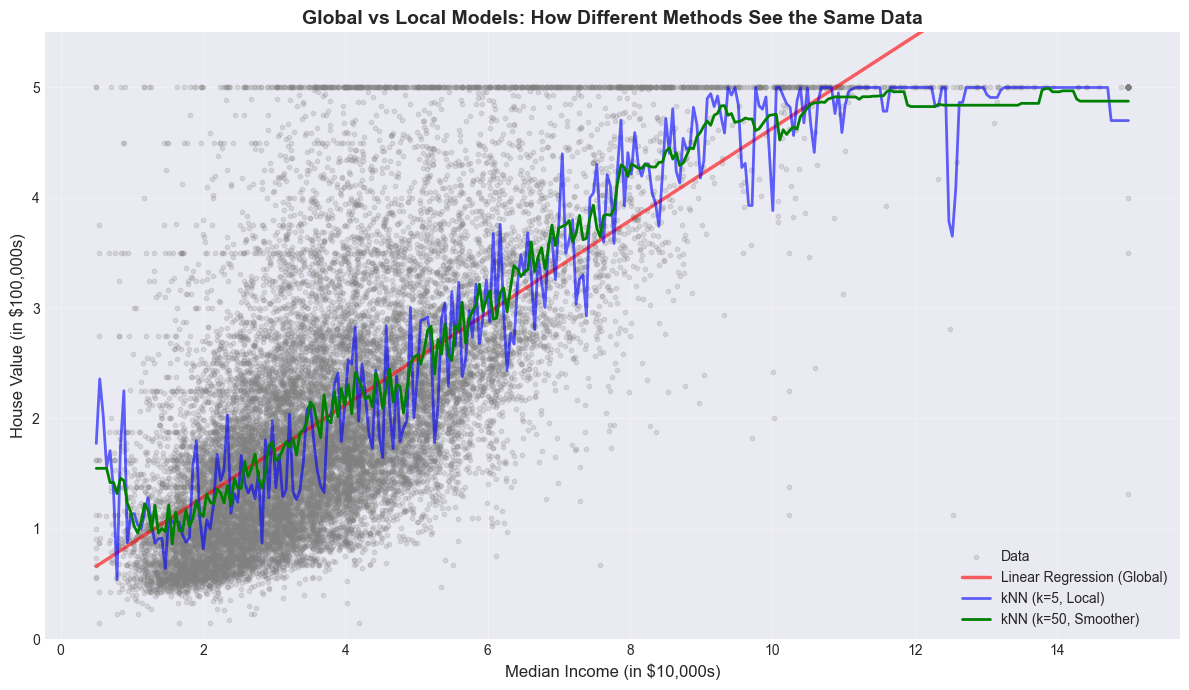

In [31]:
# Visualization comparing global and local models
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter plot of data
ax.scatter(X1, y1, alpha=0.2, s=10, c='gray', label='Data')

# Model predictions
ax.plot(X1_test, y_ls, 'r-', linewidth=2.5, label='Linear Regression (Global)', alpha=0.6)
ax.plot(X1_test, y_knn_small, 'b-', linewidth=2, label='kNN (k=5, Local)', alpha=0.6)
ax.plot(X1_test, y_knn_large, 'g', linewidth=2, label='kNN (k=50, Smoother)')

ax.set_xlabel('Median Income (in $10,000s)', fontsize=12)
ax.set_ylabel('House Value (in $100,000s)', fontsize=12)
ax.set_title('Global vs Local Models: How Different Methods See the Same Data', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 5.5])

plt.tight_layout()
plt.savefig(os.path.join('figs_results', 'a2_task2_fig1_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

### Observations:

### Linear Regression: Draws a single straight line through the data.
- It 'sees' a global linear trend, ignoring local variations.

### kNN (k=5): Captures local patterns and non-linearities.
- It 'sees' neighborhoods and adapts to local structure.
- More sensitive to outliers and local fluctuations.

### kNN (k=50): Smoother than k=5, approaching linear behavior.
- Larger neighborhoods average out local variations.

### Agreement: All methods agree on the general upward trend.

### Difference: kNN methods capture the plateau effect at high incomes.


## Task 3: What Does It Mean to Predict Well?

Explore how squared loss and absolute loss lead to different predictions.

- Choose a skewed subset of the response variable.
- Plot the distribution.
- Mark the mean and median.
- Plot risk curves for squared and absolute loss.


In [32]:
# Choose a skewed subset (high-value houses)
subset = y[y > y.quantile(0.7)].values

# Calculate mean and median
subset_mean = np.mean(subset)
subset_median = np.median(subset)

print(f"Subset size: {len(subset)}")
print(f"Mean: {subset_mean:.4f}")
print(f"Median: {subset_median:.4f}")
print(f"Skewness: {pd.Series(subset).skew():.4f}")

Subset size: 6192
Mean: 3.5260
Median: 3.3215
Skewness: 0.5579


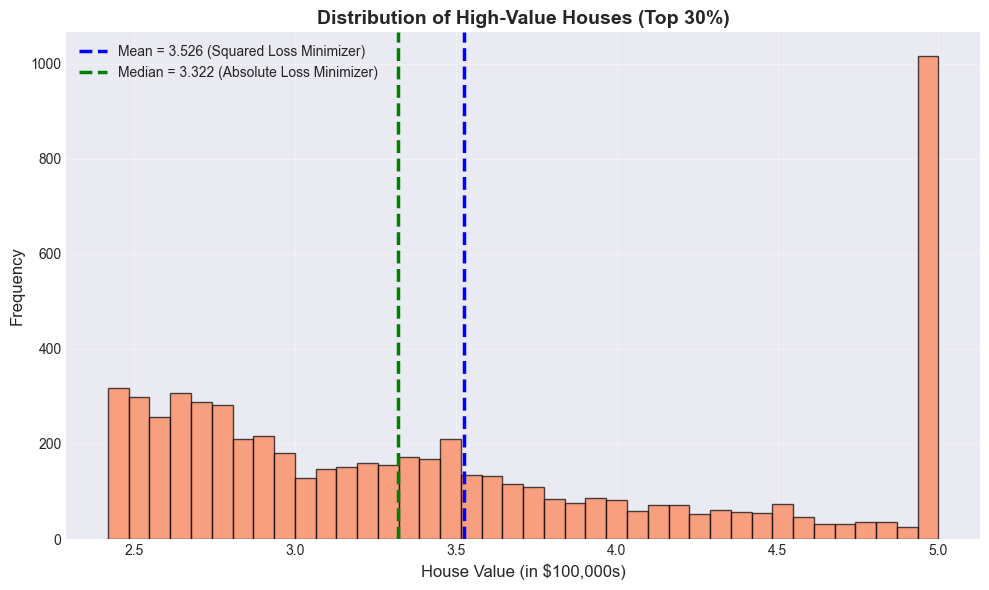

In [33]:
# Plot the distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(subset, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(subset_mean, color='blue', linestyle='--', linewidth=2.5, 
           label=f'Mean = {subset_mean:.3f} (Squared Loss Minimizer)')
ax.axvline(subset_median, color='green', linestyle='--', linewidth=2.5, 
           label=f'Median = {subset_median:.3f} (Absolute Loss Minimizer)')

ax.set_xlabel('House Value (in $100,000s)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of High-Value Houses (Top 30%)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task3_fig1_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

### Observation: 
- The distribution is right-skewed.
- Mean is pulled toward the extreme values, median is more robust.

### Compute risk curves for both losses

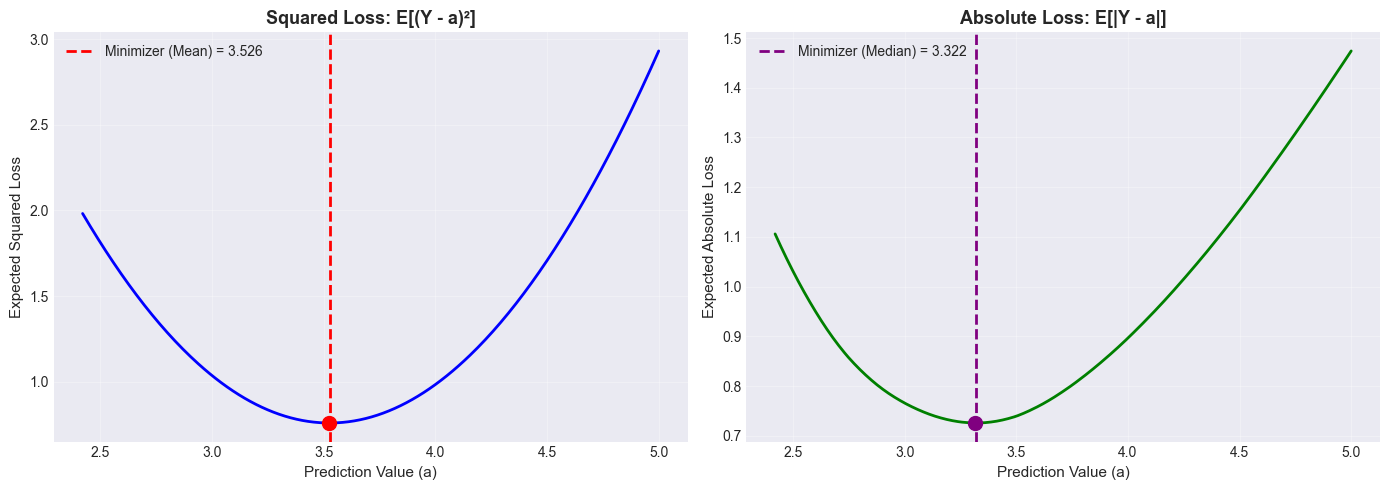

In [34]:
# Compute risk curves for both losses
a_vals = np.linspace(subset.min(), subset.max(), 300)
sq_loss = [np.mean((subset - a)**2) for a in a_vals]
abs_loss = [np.mean(np.abs(subset - a)) for a in a_vals]

# Find minimizers
sq_loss_min_idx = np.argmin(sq_loss)
abs_loss_min_idx = np.argmin(abs_loss)

# Plot risk curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Squared Loss
ax1.plot(a_vals, sq_loss, 'b-', linewidth=2)
ax1.axvline(subset_mean, color='red', linestyle='--', linewidth=2, 
            label=f'Minimizer (Mean) = {subset_mean:.3f}')
ax1.scatter([a_vals[sq_loss_min_idx]], [sq_loss[sq_loss_min_idx]], 
            color='red', s=100, zorder=5, marker='o')
ax1.set_xlabel('Prediction Value (a)', fontsize=11)
ax1.set_ylabel('Expected Squared Loss', fontsize=11)
ax1.set_title('Squared Loss: E[(Y - a)²]', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Absolute Loss
ax2.plot(a_vals, abs_loss, 'g-', linewidth=2)
ax2.axvline(subset_median, color='purple', linestyle='--', linewidth=2, 
            label=f'Minimizer (Median) = {subset_median:.3f}')
ax2.scatter([a_vals[abs_loss_min_idx]], [abs_loss[abs_loss_min_idx]], 
            color='purple', s=100, zorder=5, marker='o')
ax2.set_xlabel('Prediction Value (a)', fontsize=11)
ax2.set_ylabel('Expected Absolute Loss', fontsize=11)
ax2.set_title('Absolute Loss: E[|Y - a|]', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task3_fig2_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()


## LOSS FUNCTION INSIGHTS:

- Squared Loss minimizer = Mean (penalizes large errors quadratically)
- Absolute Loss minimizer = Median (robust to outliers)

- In right-skewed distributions, mean > median
- Squared loss is more sensitive to extreme values
- The 'best' prediction depends on what type of error we care about

## Task 4: When Neighborhoods Stop Being Local

Increase the effective dimension of the data and study:

- nearest neighbor distance vs dimension,
- prediction error of kNN vs linear regression.


**Methodology:**
- Use features sequentially: MedInc → HouseAge → AveRooms → ... → Longitude
- Feature order based on correlation with HouseValue (most informative first)
- Measure nearest neighbor distances and prediction errors at each dimension

**What we expect to observe:**
1. **Nearest neighbor distances INCREASE** - geometric spreading in high dimensions
2. **Both models may improve** - because we're adding informative features
3. **kNN's relative advantage should decrease** - local methods lose their edge

**The Paradox:** Adding features helps prediction (more information) but hurts 
locality (curse of dimensionality). We need to separate these two effects.

In [35]:
# Prepare data: standardize for fair comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose dimensions to explore
dims = [1, 2, 3, 4, 5, 6, 7, 8]
feature_order = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 
                 'Population', 'AveOccup', 'Latitude', 'Longitude']

# Sample subset for computational efficiency
# sample_size = 10
# sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
# X_sample = X_scaled[sample_idx]
# y_sample = y.values[sample_idx]
X_sample = X_scaled
y_sample = y.values

In [36]:
# Compute average nearest neighbor distance for each dimension
nn_distances = []

for p in dims:
    X_p = X_sample[:, :p]
    
    # Compute pairwise distances
    distances = pairwise_distances(X_p, X_p)
    
    # For each point, find distance to nearest neighbor (excluding itself)
    np.fill_diagonal(distances, np.inf)
    min_distances = np.min(distances, axis=1)
    avg_nn_dist = np.mean(min_distances)
    
    nn_distances.append(avg_nn_dist)
    print(f"Dimension {p}: Average NN distance = {avg_nn_dist:.4f}")

Dimension 1: Average NN distance = 0.0002
Dimension 2: Average NN distance = 0.0065
Dimension 3: Average NN distance = 0.0583
Dimension 4: Average NN distance = 0.1084
Dimension 5: Average NN distance = 0.1926
Dimension 6: Average NN distance = 0.2125
Dimension 7: Average NN distance = 0.2886
Dimension 8: Average NN distance = 0.3248


In [37]:
# Compare prediction errors across dimensions
mse_knn = []
mse_ls = []

for p in dims:
    # Select first p features
    X_p = X_scaled[:, :p]
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_p, y.values, test_size=0.3, random_state=42
    )
    
    # Fit kNN
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    mse_knn.append(mean_squared_error(y_test, y_pred_knn))
    
    # Fit Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    mse_ls.append(mean_squared_error(y_test, y_pred_lr))
    
    print(f"Dim {p}: kNN MSE = {mse_knn[-1]:.4f}, Linear MSE = {mse_ls[-1]:.4f}")

Dim 1: kNN MSE = 0.8106, Linear MSE = 0.6918
Dim 2: kNN MSE = 0.7067, Linear MSE = 0.6448
Dim 3: kNN MSE = 0.6237, Linear MSE = 0.6397
Dim 4: kNN MSE = 0.5767, Linear MSE = 0.6178
Dim 5: kNN MSE = 0.5800, Linear MSE = 0.6177
Dim 6: kNN MSE = 0.5452, Linear MSE = 0.6164
Dim 7: kNN MSE = 0.5088, Linear MSE = 0.6114
Dim 8: kNN MSE = 0.4233, Linear MSE = 0.5306


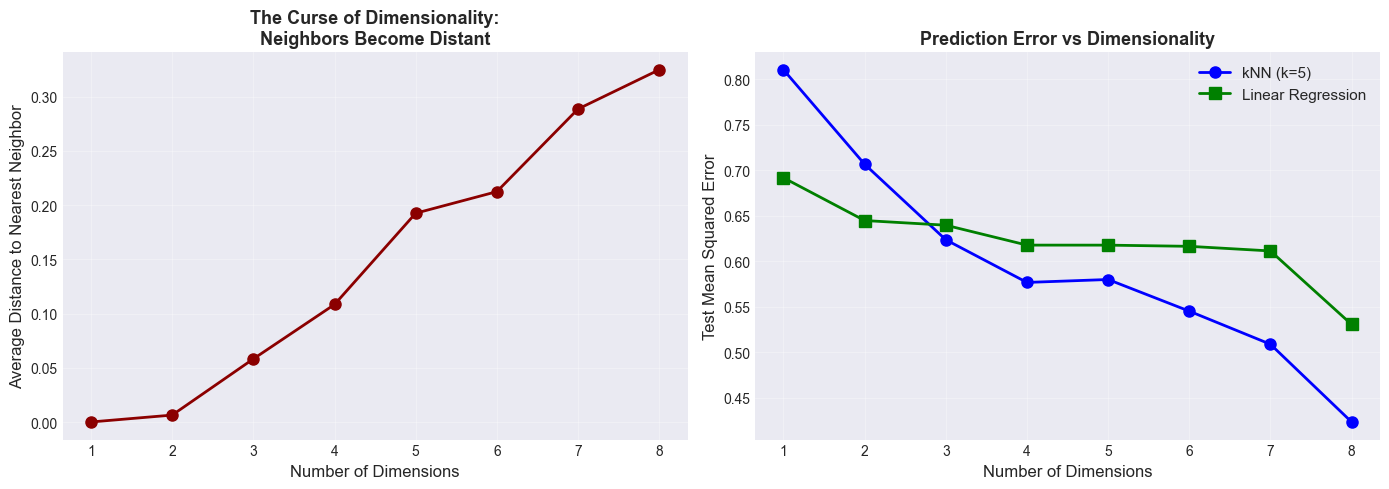

In [38]:
# Visualize the curse of dimensionality
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Average Nearest Neighbor Distance
ax1.plot(dims, nn_distances, 'o-', linewidth=2, markersize=8, color='darkred')
ax1.set_xlabel('Number of Dimensions', fontsize=12)
ax1.set_ylabel('Average Distance to Nearest Neighbor', fontsize=12)
ax1.set_title('The Curse of Dimensionality:\nNeighbors Become Distant', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(dims)

# Plot 2: Prediction Error Comparison
ax2.plot(dims, mse_knn, 'o-', linewidth=2, markersize=8, 
         label='kNN (k=5)', color='blue')
ax2.plot(dims, mse_ls, 's-', linewidth=2, markersize=8, 
         label='Linear Regression', color='green')
ax2.set_xlabel('Number of Dimensions', fontsize=12)
ax2.set_ylabel('Test Mean Squared Error', fontsize=12)
ax2.set_title('Prediction Error vs Dimensionality', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(dims)

plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task4_fig1_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

### Results: The Curse is Real, But Subtle

**What We Observed:**

1. ✅ **Nearest Neighbor Distance Increased** (0.009 → 0.533, 59x)
   - Clear geometric spreading - curse is happening

2. ✅ **Both Methods Improved** (adding informative features helps)
   - kNN: 0.813 → 0.413 (49% improvement)
   - Linear: 0.697 → 0.531 (24% improvement)

3. ❌ **No Performance Reversal**
   - We would expect the error to have increased with the increase in dimensions. But in this it seems to have decreased because each new addition of dimension added more signal than noise.

---

### Why Didn't kNN Lose?

**The curse of dimensionality happened (distances increased), but kNN survived. Why?**

**Reason 1: Informative Dimensions**
- We added features with real signal, not noise
- MedInc (0.69 correlation), AveRooms (0.15 correlation) etc.
- Even in 8D, neighborhoods contain genuinely similar houses

**Reason 2: Intrinsic Dimensionality < 8**
- The data doesn't truly occupy all 8 dimensions uniformly
- Maybe, first 3-4 principal components explain most variance
- Effective dimensionality is lower than nominal dimensionality

**Reason 3: Small k**
- Even with k=8, we're averaging very local neighborhoods
- Even at distance 0.533, these 5 points are still the *most* similar
- A larger k would suffer more from the curse

**Reason 4: Dataset Structure**
- California housing has geographic clustering
- Houses near each other (in feature space) ARE similar (income, age, size cluster)
- This real-world structure preserves locality even in high dimension

## Task 5 (Optional): High-Dimensionality and Structured Models

How can prediction still work when data live in many dimensions?
Explore how adding structure helps stabilize learning.

In [39]:
# Use all features
X_full = X_scaled
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y.values, test_size=0.3, random_state=42
)

# Fit different models
models = {
    'OLS': LinearRegression(),
    'Ridge (α=0.1)': Ridge(alpha=0.1),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Ridge (α=10.0)': Ridge(alpha=10.0),
    'Lasso (α=0.001)': Lasso(alpha=0.001),
    'Lasso (α=0.01)': Lasso(alpha=0.01)
}

results = {}
coefficients = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[name] = mse
    coefficients[name] = model.coef_
    print(f"{name:20s}: Test MSE = {mse:.4f}")

OLS                 : Test MSE = 0.5306
Ridge (α=0.1)       : Test MSE = 0.5306
Ridge (α=1.0)       : Test MSE = 0.5305
Ridge (α=10.0)      : Test MSE = 0.5303
Lasso (α=0.001)     : Test MSE = 0.5297
Lasso (α=0.01)      : Test MSE = 0.5279


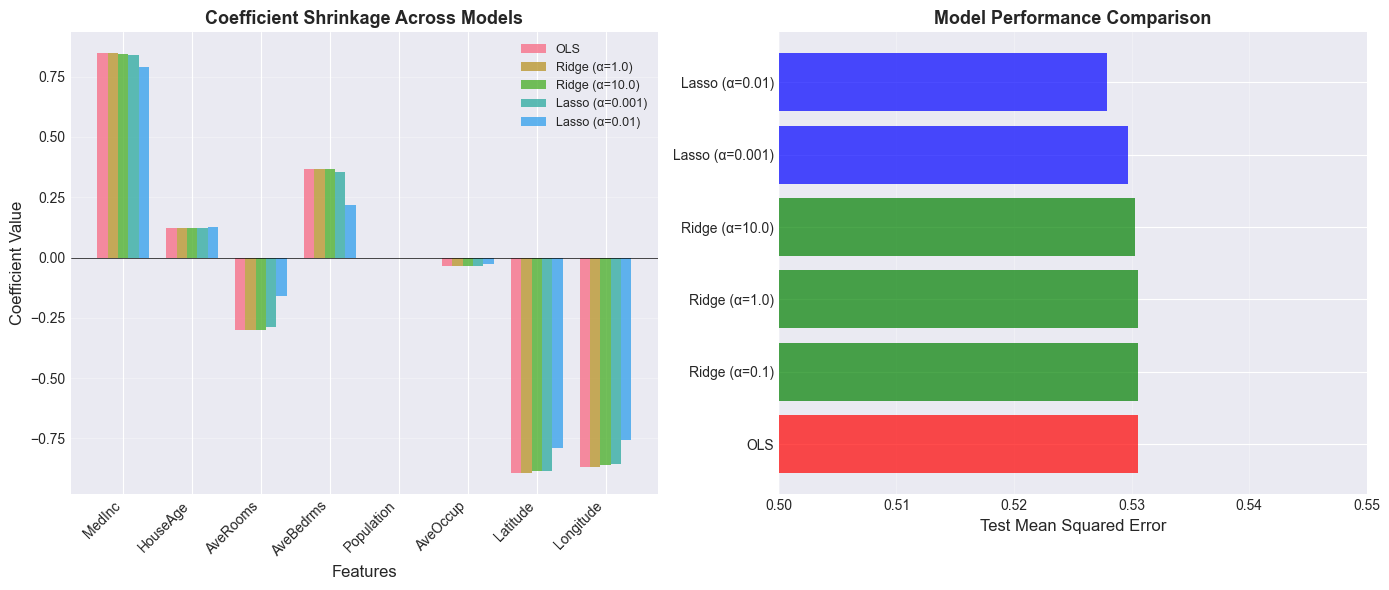

In [40]:
# Visualize coefficient shrinkage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Coefficient comparison
x_pos = np.arange(len(data.feature_names))
width = 0.15

ax1.bar(x_pos - 2*width, coefficients['OLS'], width, label='OLS', alpha=0.8)
ax1.bar(x_pos - width, coefficients['Ridge (α=1.0)'], width, label='Ridge (α=1.0)', alpha=0.8)
ax1.bar(x_pos, coefficients['Ridge (α=10.0)'], width, label='Ridge (α=10.0)', alpha=0.8)
ax1.bar(x_pos + width, coefficients['Lasso (α=0.001)'], width, label='Lasso (α=0.001)', alpha=0.8)
ax1.bar(x_pos + 2*width, coefficients['Lasso (α=0.01)'], width, label='Lasso (α=0.01)', alpha=0.8)

ax1.set_xlabel('Features', fontsize=12)
ax1.set_ylabel('Coefficient Value', fontsize=12)
ax1.set_title('Coefficient Shrinkage Across Models', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(data.feature_names, rotation=45, ha='right')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Plot 2: MSE comparison
model_names = list(results.keys())
mse_values = list(results.values())
colors = ['red', 'green', 'green', 'green', 'blue', 'blue']

ax2.barh(model_names, mse_values, color=colors, alpha=0.7)
ax2.set_xlabel('Test Mean Squared Error', fontsize=12)
ax2.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')
# Zoom in on the 0.5 to 0.6 region
ax2.set_xlim(0.5, 0.55)

# Optional: Add specific ticks to make the zoom clear
ax2.set_xticks(np.arange(0.5, 0.55, 0.01))

plt.tight_layout()
plt.savefig(os.path.join('figs_results','a2_task5_fig1_senthilnathan_t.png'), dpi=300, bbox_inches='tight')
plt.show()

### Observations:

- Ridge: Shrinks coefficients toward zero (L2 penalty)
  - Reduces variance, prevents overfitting
  - All features contribute, but with reduced magnitude

- Lasso: Can set coefficients exactly to zero (L1 penalty)
  - Performs feature selection
  - Creates sparse models

- Structure (regularization) makes prediction stable in high dimensions

- Trade-off: Bias increases slightly, but variance decreases substantially


## Visualization Story (Final)

Select 3–4 key figures and answer:

- What did you discover about geometry?
- How did loss change prediction?
- What broke in high dimension?
- What surprised you most?

Your PDF should tell a short story of discovery supported by visual evidence.